# MTF Kernel

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def optical_mtf(f, f_number, wavelength):
    """
    Calculate the optical MTF for a given spatial frequency, F-number, and wavelength.
    
    Parameters:
    - f: Spatial frequency (cycles/mm)
    - f_number: F-number of the optical system
    - wavelength: Wavelength of light (mm)
    
    Returns:
    - MTF value for the given frequency.
    """
    f_c = 1 / (wavelength * f_number)  # Cutoff frequency
    # Apply the formula for optical MTF
    if np.abs(f) > f_c:
        return 0
    else:
        return (2 / np.pi) * (np.arccos(f / f_c) - (f / f_c) * np.sqrt(1 - (f / f_c) ** 2))

def detector_mtf(f, pixel_pitch):
    """
    Calculate the detector MTF using the sinc function.
    
    Parameters:
    - f: Spatial frequency (cycles/mm)
    - pixel_pitch: Pixel pitch (mm)
    
    Returns:
    - MTF value for the given frequency.
    """
    return np.sinc(f * pixel_pitch)

def total_mtf(fx, fy, f_number, wavelength, pixel_pitch):
    """
    Calculate the total MTF (Optical + Detector) for given spatial frequencies.
    
    Parameters:
    - fx, fy: Spatial frequencies (cycles/mm) in x and y directions
    - f_number: F-number of the optical system
    - wavelength: Wavelength of light (mm)
    - pixel_pitch: Pixel pitch (mm)
    
    Returns:
    - Total MTF value.
    """
    f = np.sqrt(fx**2 + fy**2)
    return optical_mtf(f, f_number, wavelength) * detector_mtf(f, pixel_pitch)

# Parameters
def get_venus_params():
    # https://www.eoportal.org/satellite-missions/venus#VENuS.html.6
    # https://en.wikipedia.org/wiki/VENμS
    
    # Pixel pitch and F-number for VENµS Super Spectral Camera (VSSC)
    f_number = 7.  # F-number for the VENµS VSSC
    pixel_pitch = 0.0169  # Pixel pitch in mm 5200 pixels in 88 mm
    MTF_at_nyquist = 0.2 # https://www.spiedigitallibrary.org/conference-proceedings-of-spie/11180/111804F/Measuring-modeling-and-removing-optical-straylight-from-venμs-super-spectral/10.1117/12.2536078.full
    params = {'f_number': f_number, 'pixel_pitch': pixel_pitch, 'MTF_at_nyquist': MTF_at_nyquist}
    return params

def get_sen2_params():
    aperture =  150 # mm 
    focal_length = 600 # mm
    MTF_at_nyquist = 0.3
    f_number = focal_length / aperture
    pixel_pitch = None
    params = {'f_number': f_number, 'pixel_pitch': pixel_pitch, 'MTF_at_nyquist': MTF_at_nyquist}
    return params


# n = 7  # Size of the MTF kernel
# wavelength = 0.0008  # Wavelength in mm (800 nm)
# f_number, pixel_pitch = get_venus_params()

# # Generate MTF kernel
# mtf_kernel = np.zeros((n, n))
# fx_range = np.linspace(-0.5, 0.5, n)  # Spatial frequency range
# fy_range = np.linspace(-0.5, 0.5, n)

# for i, fx in enumerate(fx_range):
#     for j, fy in enumerate(fy_range):
#         mtf_kernel[i, j] = total_mtf(fx, fy, f_number, wavelength, pixel_pitch)

# # Plot the MTF kernel
# mtf_kernel = mtf_kernel / mtf_kernel.sum()
# plt.imshow(mtf_kernel, extent=(-0.5, 0.5, -0.5, 0.5), cmap='viridis')
# plt.colorbar(label='MTF')
# plt.title('2D MTF Kernel')
# plt.xlabel('Spatial Frequency (cycles/mm) in X')
# plt.ylabel('Spatial Frequency (cycles/mm) in Y')
# plt.show()

# NOISE

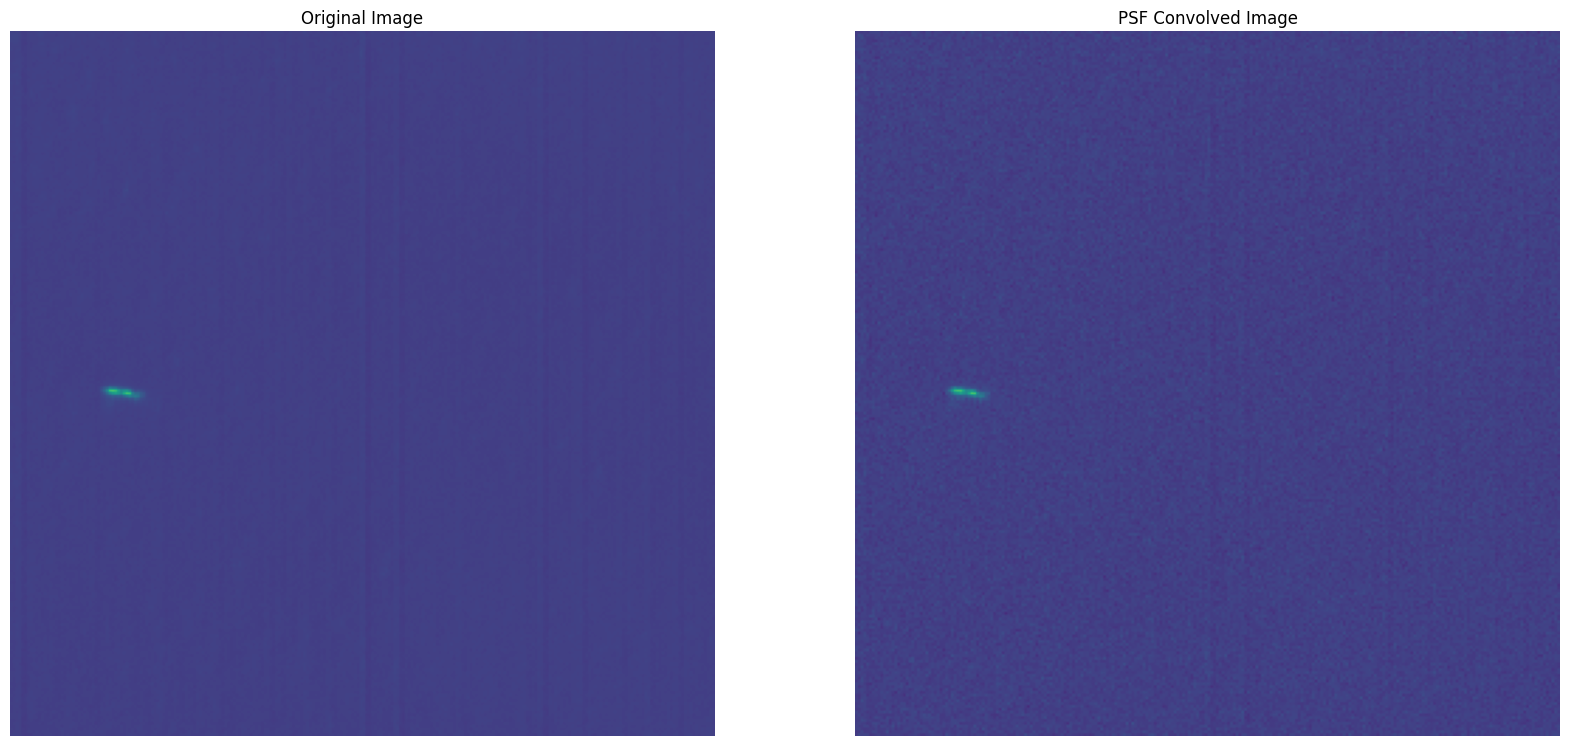

In [15]:
import matplotlib.pyplot as plt
import rasterio as rio 

venus_optics = OpticalSystem('venus', 0.2, SNR=10)


VMIN = 0
VMAX = 200




def read_tiff(path):
    with rio.open(path) as src:
        return src.read(10)
    
img = read_tiff('/Data_large/marine/Datasets/VENuS/ds_L0/perfect/ASH_L0_12430_20191207_MultiLayer_mask_OK.tif')



fig, axes = plt.subplots(1, 2, figsize=(20, 15))
# Plot the original image
axes[0].imshow(img[1500:1750, 500:750], vmin=VMIN, vmax=VMAX)
axes[0].axis('off')
axes[0].set_title('Original Image')
# Plot the PSF convolved image
axes[1].imshow(venus_optics.apply(img)[1500:1750, 500:750], 
               vmin=VMIN, vmax=VMAX)
axes[1].axis('off')
axes[1].set_title('PSF Convolved Image')
plt.show()